In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/edat_lfse_24.csv")

print(df.shape)
df.head()

(4945, 17)


,freq,duration,isced11,age,sex,unit,geo,time,value,freq_label,duration_label,isced11_label,age_label,sex_label,unit_label,geo_label,time_label
0,A,TOTAL,TOTAL,Y15-34,T,PC,EL,2014,54.8,Annual,Total,All ISCED 2011 levels,From 15 to 34 years,Total,Percentage,Greece,2014
1,A,TOTAL,TOTAL,Y15-34,T,PC,EL,2015,57.6,Annual,Total,All ISCED 2011 levels,From 15 to 34 years,Total,Percentage,Greece,2015
2,A,TOTAL,TOTAL,Y15-34,T,PC,EL,2016,58.7,Annual,Total,All ISCED 2011 levels,From 15 to 34 years,Total,Percentage,Greece,2016
3,A,TOTAL,TOTAL,Y15-34,T,PC,EL,2017,60.4,Annual,Total,All ISCED 2011 levels,From 15 to 34 years,Total,Percentage,Greece,2017
4,A,TOTAL,TOTAL,Y15-34,T,PC,EL,2018,62.7,Annual,Total,All ISCED 2011 levels,From 15 to 34 years,Total,Percentage,Greece,2018


In [2]:
dimensions = [
    "sex",
    "age",
    "isced11",
    "duration",
    "unit",
    "geo"
]

for column in dimensions:
    label_column = f"{column}_label"

    print(f"\n--- {column} ---")
    print(
        df[[column, label_column]]
        .drop_duplicates()
        .sort_values(column)
        .to_string(index=False)
    )


--- sex ---
sex sex_label
  F   Females
  M     Males
  T     Total

--- age ---
   age           age_label
Y15-34 From 15 to 34 years
Y18-34 From 18 to 34 years
Y20-34 From 20 to 34 years

--- isced11 ---
isced11                                                                                isced11_label
  ED0-2                        Less than primary, primary and lower secondary education (levels 0-2)
  ED0-4 Less than primary, primary, secondary and post-secondary non-tertiary education (levels 0-4)
  ED3-8             Upper secondary, post-secondary non-tertiary and tertiary education (levels 3-8)
ED34_44       Upper secondary and post-secondary non-tertiary education - general (levels 34 and 44)
ED35_45    Upper secondary and post-secondary non-tertiary education - vocational (levels 35 and 45)
  ED3_4                   Upper secondary and post-secondary non-tertiary education (levels 3 and 4)
  ED5-8                                                              Tertiary educatio

In [3]:
filtered = df[
    (df["sex"] == "T") &
    (df["age"] == "Y20-34") &
    (df["duration"] == "Y1-3") &
    (df["unit"] == "PC")
].copy()

filtered[
    ["isced11", "isced11_label"]
].drop_duplicates()

,isced11,isced11_label
936,TOTAL,All ISCED 2011 levels
1044,ED0-4,"Less than primary, primary, secondary and post..."
1097,ED0-2,"Less than primary, primary and lower secondary..."
1173,ED3-8,"Upper secondary, post-secondary non-tertiary a..."
1281,ED3_4,Upper secondary and post-secondary non-tertiar...
1387,ED34_44,Upper secondary and post-secondary non-tertiar...
1491,ED35_45,Upper secondary and post-secondary non-tertiar...
1599,ED5-8,Tertiary education (levels 5-8)


In [4]:
filtered["time"] = pd.to_numeric(
    filtered["time"],
    errors="coerce"
)

filtered["value"] = pd.to_numeric(
    filtered["value"],
    errors="coerce"
)

filtered = (
    filtered
    .dropna(subset=["time", "value"])
    .sort_values("time")
)

filtered[
    ["time", "isced11_label", "value"]
].head(20)

,time,isced11_label,value
936,2014,All ISCED 2011 levels,44.0
1173,2014,"Upper secondary, post-secondary non-tertiary a...",44.3
1387,2014,Upper secondary and post-secondary non-tertiar...,33.4
1491,2014,Upper secondary and post-secondary non-tertiar...,41.6
1044,2014,"Less than primary, primary, secondary and post...",38.1
1599,2014,Tertiary education (levels 5-8),47.4
1281,2014,Upper secondary and post-secondary non-tertiar...,38.8
1600,2015,Tertiary education (levels 5-8),49.9
1174,2015,"Upper secondary, post-secondary non-tertiary a...",45.2
937,2015,All ISCED 2011 levels,45.0


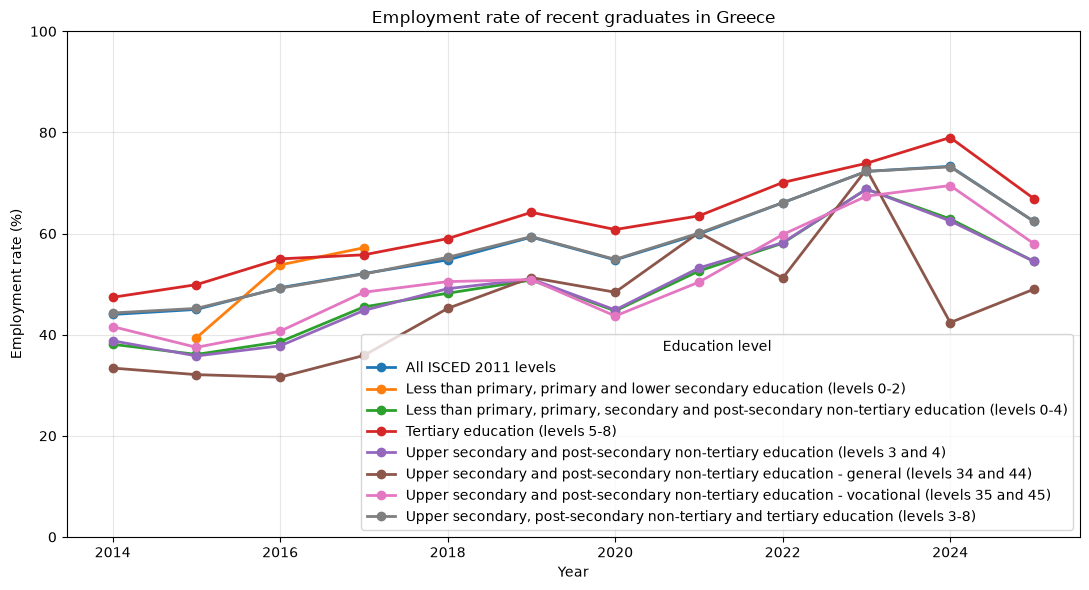

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

for education, group in filtered.groupby("isced11_label"):
    ax.plot(
        group["time"],
        group["value"],
        marker="o",
        linewidth=2,
        label=education
    )

ax.set_title(
    "Employment rate of recent graduates in Greece"
)
ax.set_xlabel("Year")
ax.set_ylabel("Employment rate (%)")
ax.grid(alpha=0.3)
ax.legend(title="Education level")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [6]:
fig.savefig(
    "../outputs/figures/greece_recent_graduates.png",
    dpi=300,
    bbox_inches="tight"
)

In [7]:
eu_df = pd.read_csv(
    "../data/processed/recent_graduates_all_countries.csv"
)

eu_df["time"] = pd.to_numeric(eu_df["time"])
eu_df["value"] = pd.to_numeric(eu_df["value"])

print(eu_df.shape)
eu_df.head()

(3161, 17)


,freq,duration,isced11,age,sex,unit,geo,time,value,freq_label,duration_label,isced11_label,age_label,sex_label,unit_label,geo_label,time_label
0,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2014,73.6,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2014
1,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2015,74.3,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2015
2,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2016,76.2,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2016
3,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2017,77.9,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2017
4,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2018,79.8,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2018


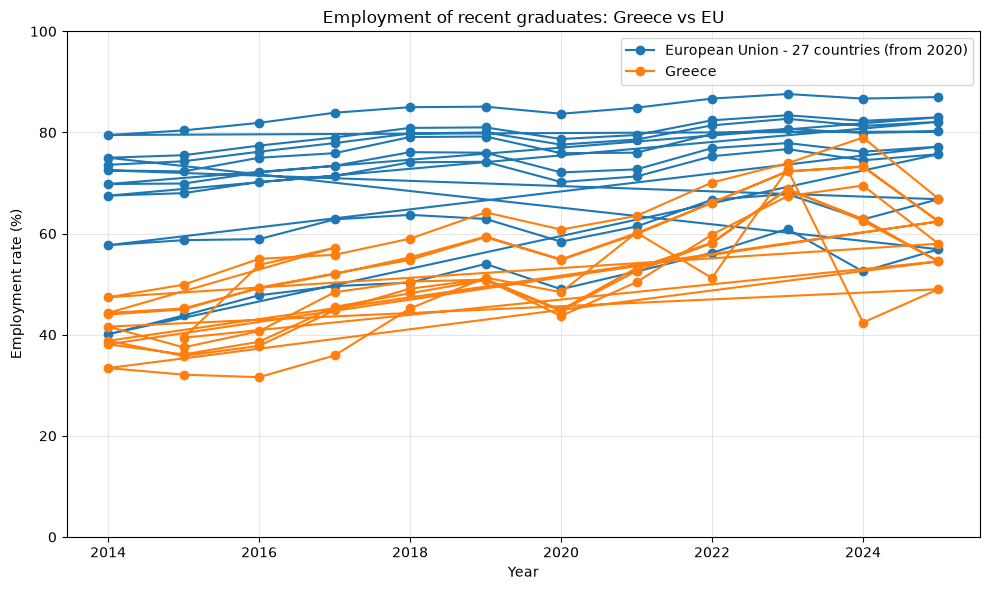

In [8]:
comparison = eu_df[
    eu_df["geo"].isin(["EL", "EU27_2020"])
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for country, group in comparison.groupby("geo_label"):
    ax.plot(
        group["time"],
        group["value"],
        marker="o",
        label=country
    )

ax.set_title("Employment of recent graduates: Greece vs EU")
ax.set_xlabel("Year")
ax.set_ylabel("Employment rate (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

eu_df = pd.read_csv("../data/processed/recent_graduates_all_countries.csv")

print(eu_df.shape)
eu_df.head()

(3161, 17)


,freq,duration,isced11,age,sex,unit,geo,time,value,freq_label,duration_label,isced11_label,age_label,sex_label,unit_label,geo_label,time_label
0,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2014,73.6,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2014
1,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2015,74.3,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2015
2,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2016,76.2,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2016
3,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2017,77.9,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2017
4,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2018,79.8,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2018


In [10]:
eu_df[["isced11", "isced11_label"]].drop_duplicates()

,isced11,isced11_label
0,TOTAL,All ISCED 2011 levels
436,ED0-4,"Less than primary, primary, secondary and post..."
871,ED0-2,"Less than primary, primary and lower secondary..."
1040,ED3-8,"Upper secondary, post-secondary non-tertiary a..."
1476,ED3_4,Upper secondary and post-secondary non-tertiar...
1911,ED34_44,Upper secondary and post-secondary non-tertiar...
2298,ED35_45,Upper secondary and post-secondary non-tertiar...
2725,ED5-8,Tertiary education (levels 5-8)


In [11]:
eu_df["time"] = pd.to_numeric(eu_df["time"], errors="coerce")
eu_df["value"] = pd.to_numeric(eu_df["value"], errors="coerce")

tertiary = eu_df[
    (eu_df["isced11"] == "ED5-8") &
    (eu_df["geo"].isin(["EL", "EU27_2020"]))
].copy()

tertiary = tertiary.sort_values(["geo", "time"])

tertiary[["geo", "geo_label", "time", "value"]].head(20)

,geo,geo_label,time,value
2833,EL,Greece,2014,47.4
2834,EL,Greece,2015,49.9
2835,EL,Greece,2016,55.0
2836,EL,Greece,2017,55.8
2837,EL,Greece,2018,59.0
2838,EL,Greece,2019,64.2
2839,EL,Greece,2020,60.8
2840,EL,Greece,2021,63.5
2841,EL,Greece,2022,70.1
2842,EL,Greece,2023,73.9


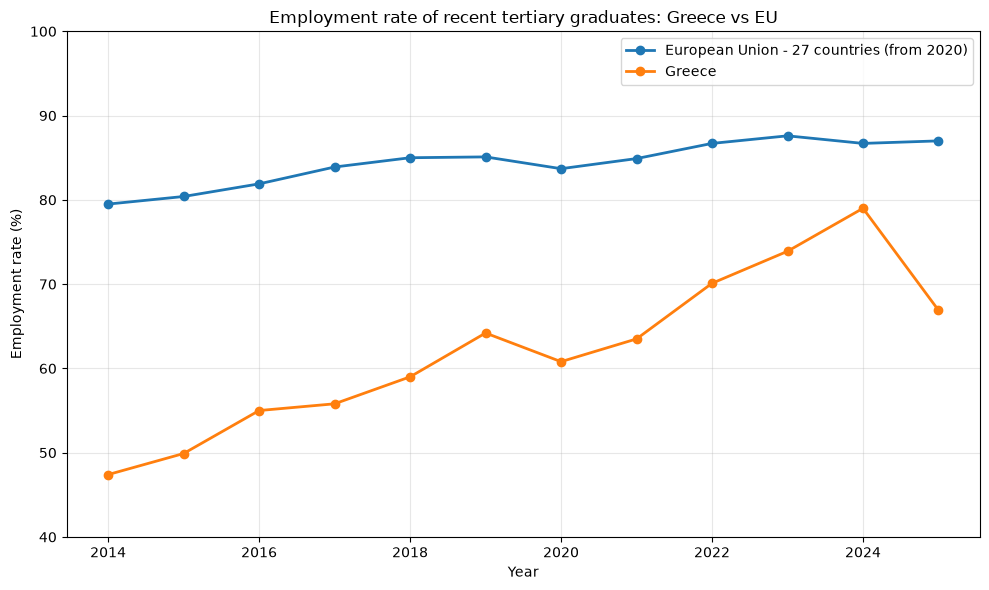

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for country, group in tertiary.groupby("geo_label"):
    ax.plot(
        group["time"],
        group["value"],
        marker="o",
        linewidth=2,
        label=country
    )

ax.set_title("Employment rate of recent tertiary graduates: Greece vs EU")
ax.set_xlabel("Year")
ax.set_ylabel("Employment rate (%)")
ax.set_ylim(40, 100)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
fig.savefig(
    "../outputs/figures/greece_vs_eu_tertiary_graduates.png",
    dpi=300,
    bbox_inches="tight"
)

In [15]:
eu_df = pd.read_csv("../data/processed/recent_graduates_all_countries.csv")

print(eu_df.shape)
eu_df.head()

(3161, 17)


,freq,duration,isced11,age,sex,unit,geo,time,value,freq_label,duration_label,isced11_label,age_label,sex_label,unit_label,geo_label,time_label
0,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2014,73.6,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2014
1,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2015,74.3,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2015
2,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2016,76.2,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2016
3,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2017,77.9,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2017
4,A,Y1-3,TOTAL,Y20-34,T,PC,EU27_2020,2018,79.8,Annual,From 1 to 3 years,All ISCED 2011 levels,From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2018


In [16]:
# Έλεγχος διαθέσιμων κατηγοριών
print(eu_df["isced11"].unique())
print(eu_df["geo"].unique())

<ArrowStringArray>
['TOTAL', 'ED0-4', 'ED0-2', 'ED3-8', 'ED3_4', 'ED34_44', 'ED35_45', 'ED5-8']
Length: 8, dtype: str
<ArrowStringArray>
['EU27_2020',      'EA21',        'BE',        'BG',        'CZ',        'DK',
        'DE',        'EE',        'IE',        'EL',        'ES',        'FR',
        'HR',        'IT',        'CY',        'LV',        'LT',        'LU',
        'HU',        'MT',        'NL',        'AT',        'PL',        'PT',
        'RO',        'SI',        'SK',        'FI',        'SE',        'IS',
        'NO',        'CH',        'UK',        'BA',        'ME',        'MK',
        'RS',        'TR']
Length: 38, dtype: str


In [17]:
tertiary = eu_df[
    (eu_df["isced11"] == "ED5-8") &
    (eu_df["geo"].isin(["EL", "EU27_2020"]))
].copy()

tertiary["time"] = pd.to_numeric(tertiary["time"], errors="coerce")
tertiary["value"] = pd.to_numeric(tertiary["value"], errors="coerce")

tertiary = tertiary.dropna(subset=["time", "value"])

print(tertiary.shape)
tertiary.head()

(24, 17)


,freq,duration,isced11,age,sex,unit,geo,time,value,freq_label,duration_label,isced11_label,age_label,sex_label,unit_label,geo_label,time_label
2725,A,Y1-3,ED5-8,Y20-34,T,PC,EU27_2020,2014,79.5,Annual,From 1 to 3 years,Tertiary education (levels 5-8),From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2014
2726,A,Y1-3,ED5-8,Y20-34,T,PC,EU27_2020,2015,80.4,Annual,From 1 to 3 years,Tertiary education (levels 5-8),From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2015
2727,A,Y1-3,ED5-8,Y20-34,T,PC,EU27_2020,2016,81.9,Annual,From 1 to 3 years,Tertiary education (levels 5-8),From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2016
2728,A,Y1-3,ED5-8,Y20-34,T,PC,EU27_2020,2017,83.9,Annual,From 1 to 3 years,Tertiary education (levels 5-8),From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2017
2729,A,Y1-3,ED5-8,Y20-34,T,PC,EU27_2020,2018,85.0,Annual,From 1 to 3 years,Tertiary education (levels 5-8),From 20 to 34 years,Total,Percentage,European Union - 27 countries (from 2020),2018


In [18]:
comparison_table = tertiary.pivot_table(
    index="time",
    columns="geo",
    values="value",
    aggfunc="mean"
).reset_index()

comparison_table = comparison_table.rename(
    columns={
        "EL": "Greece",
        "EU27_2020": "EU"
    }
)

comparison_table["gap_greece_eu"] = (
    comparison_table["Greece"] - comparison_table["EU"]
)

comparison_table

geo,time,Greece,EU,gap_greece_eu
0,2014,47.4,79.5,-32.1
1,2015,49.9,80.4,-30.5
2,2016,55.0,81.9,-26.9
3,2017,55.8,83.9,-28.1
4,2018,59.0,85.0,-26.0
5,2019,64.2,85.1,-20.9
6,2020,60.8,83.7,-22.9
7,2021,63.5,84.9,-21.4
8,2022,70.1,86.7,-16.6
9,2023,73.9,87.6,-13.7


In [19]:
print("Μέσο ποσοστό Ελλάδας:")
print(round(comparison_table["Greece"].mean(), 2))

print("\nΜέσο ποσοστό ΕΕ:")
print(round(comparison_table["EU"].mean(), 2))

print("\nΜέση διαφορά Ελλάδας–ΕΕ:")
print(round(comparison_table["gap_greece_eu"].mean(), 2))

print("\nΧρονιά με τη μεγαλύτερη διαφορά:")
worst_year = comparison_table.loc[
    comparison_table["gap_greece_eu"].idxmin()
]
print(worst_year)

Μέσο ποσοστό Ελλάδας:
62.12

Μέσο ποσοστό ΕΕ:
84.37

Μέση διαφορά Ελλάδας–ΕΕ:
-22.24

Χρονιά με τη μεγαλύτερη διαφορά:
geo
time             2014.0
Greece             47.4
EU                 79.5
gap_greece_eu     -32.1
Name: 0, dtype: float64


In [20]:
comparison_table.to_csv(
    "../outputs/tables/greece_vs_eu_comparison.csv",
    index=False
)

In [21]:
comparison_table.tail()

geo,time,Greece,EU,gap_greece_eu
7,2021,63.5,84.9,-21.4
8,2022,70.1,86.7,-16.6
9,2023,73.9,87.6,-13.7
10,2024,79.0,86.7,-7.7
11,2025,66.9,87.0,-20.1


In [22]:
countries = eu_df[
    (eu_df["isced11"] == "ED5-8") &
    (eu_df["geo"].str.len() == 2)
].copy()

countries["time"] = pd.to_numeric(countries["time"], errors="coerce")
countries["value"] = pd.to_numeric(countries["value"], errors="coerce")

countries = countries.dropna(subset=["time", "value"])

latest_year = int(countries["time"].max())
latest = countries[countries["time"] == latest_year].copy()

ranking = (
    latest.groupby(["geo", "geo_label"], as_index=False)["value"]
    .mean()
    .sort_values("value", ascending=False)
)

ranking["rank"] = range(1, len(ranking) + 1)

print("Έτος:", latest_year)
ranking.head(10)

Έτος: 2025


,geo,geo_label,value,rank
9,EE,Estonia,95.9,1
23,MT,Malta,94.1,2
15,HU,Hungary,93.2,3
19,LT,Lithuania,93.2,4
16,IE,Ireland,92.7,5
7,DE,Germany,92.6,6
26,PL,Poland,92.4,7
20,LU,Luxembourg,92.4,8
24,NL,Netherlands,92.1,9
21,LV,Latvia,92.1,10


In [23]:
greece_result = ranking[ranking["geo"] == "EL"]

print(greece_result.to_string(index=False))

geo geo_label  value  rank
 EL    Greece   66.9    32


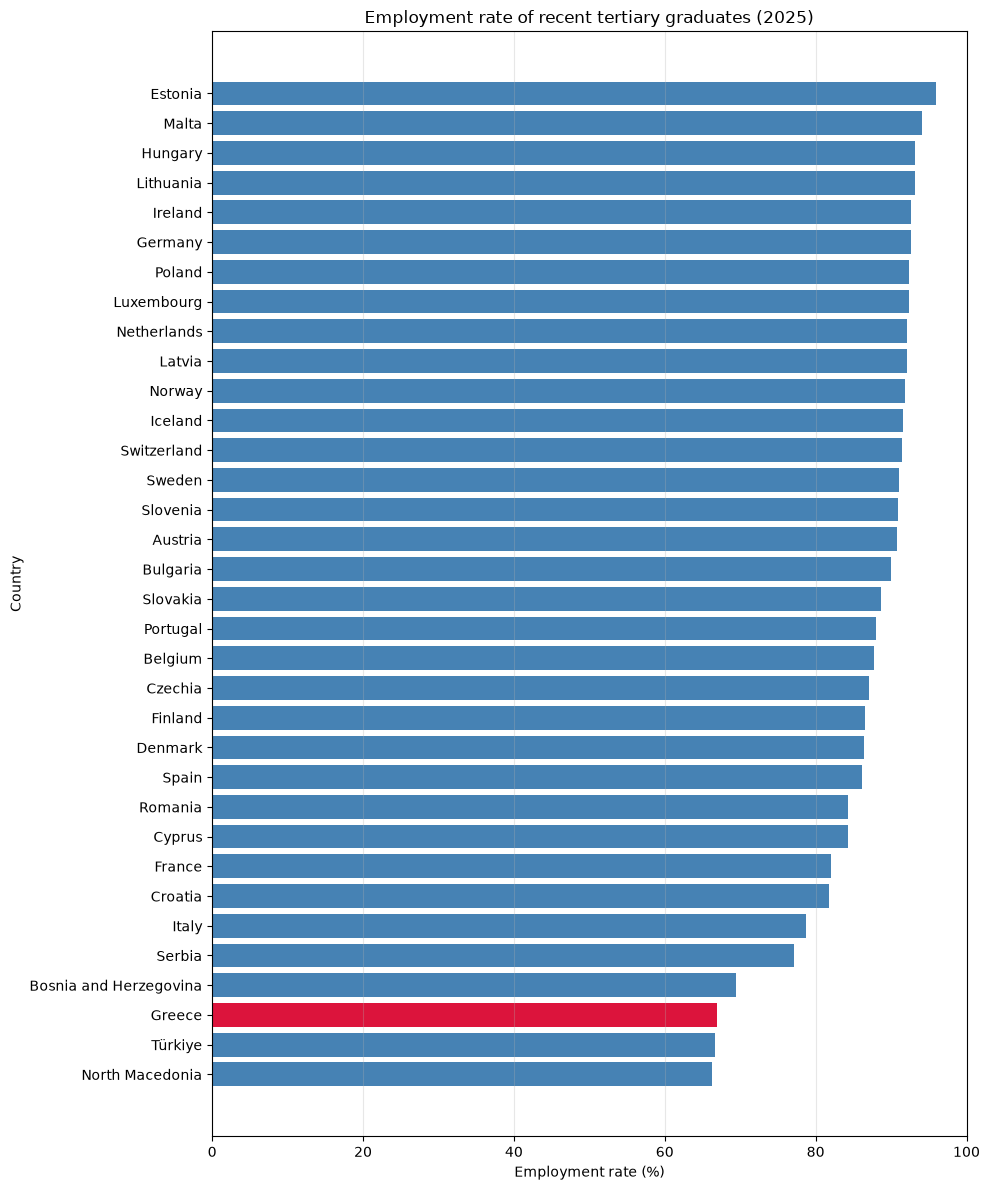

In [24]:
plot_data = ranking.sort_values("value")

colors = [
    "crimson" if code == "EL" else "steelblue"
    for code in plot_data["geo"]
]

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    plot_data["geo_label"],
    plot_data["value"],
    color=colors
)

ax.set_title(
    f"Employment rate of recent tertiary graduates ({latest_year})"
)
ax.set_xlabel("Employment rate (%)")
ax.set_ylabel("Country")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
ranking.to_csv(
    "../outputs/tables/country_ranking.csv",
    index=False
)

fig.savefig(
    "../outputs/figures/country_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

In [26]:
gr = ranking.loc[ranking["geo"] == "EL"].iloc[0]
best = ranking.iloc[0]
worst = ranking.iloc[-1]

print(f"""
Αποτελέσματα για το {latest_year}

Η Ελλάδα είχε ποσοστό απασχόλησης πρόσφατων αποφοίτων
τριτοβάθμιας εκπαίδευσης {gr['value']:.1f}% και βρισκόταν
στη θέση {int(gr['rank'])} μεταξύ {len(ranking)} χωρών.

Υψηλότερο ποσοστό:
{best['geo_label']} — {best['value']:.1f}%

Χαμηλότερο ποσοστό:
{worst['geo_label']} — {worst['value']:.1f}%
""")


Αποτελέσματα για το 2025

Η Ελλάδα είχε ποσοστό απασχόλησης πρόσφατων αποφοίτων
τριτοβάθμιας εκπαίδευσης 66.9% και βρισκόταν
στη θέση 32 μεταξύ 34 χωρών.

Υψηλότερο ποσοστό:
Estonia — 95.9%

Χαμηλότερο ποσοστό:
North Macedonia — 66.2%

